# Example 1: Symbolic Regressor

In [1]:
import sys
import os
from pathlib import Path

from numpy.core import records

# Add the parent folder (my_project) to Python's search path
sys.path.append(str(Path.cwd().parent))

%matplotlib inline
from gplearn.genetic_standard import SymbolicRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.random import check_random_state
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import graphviz
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
import math
from collections import defaultdict
import graphviz

os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

C:\Users\Khoo Zj\AppData\Local\Temp\ipykernel_10284\3435486594.py:5: DeprecationWarning: numpy.core is deprecated and has been renamed to numpy._core. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.records.
  from numpy.core import records


In [2]:
def get_benchmark_dataset(name, n_train=100, n_test=100, random_state=0):
    """
    Generates train and test datasets for standard Genetic Programming benchmarks.

    Parameters:
        name (str): Benchmark problem ('E1', 'E2', 'M1', 'M2', 'H1', 'H2')
        n_train (int): Number of training samples
        n_test (int): Number of testing samples
        random_state (int/RandomState): Seed for reproducibility

    Returns:
        X_train, y_train, X_test, y_test
    """
    rng = check_random_state(random_state)
    name = name.upper().replace("-", "").replace("_", "")

    def _generate_data(n_samples):

        # 1. Custom Domain Handling
        if name == 'NGUYEN7':
            # Sampling x from [0, 2] to prevent log(x + 1) domain errors (x <= -1)
            X = rng.uniform(0, 2, n_samples * 5).reshape(-1, 5)
        elif name == 'KEIJZER6':
            # Sampling positive values [1, 100] for harmonic number calculations
            X = rng.uniform(1, 100, n_samples * 5).reshape(-1, 5)
        else:
            # Default standard domain [-5, 5]
            X = rng.uniform(-5, 5, n_samples * 5).reshape(-1, 5)

        x1, x2, x3, x4, x5 = X[:, 0], X[:, 1], X[:, 2], X[:, 3], X[:, 4]

        # Define Function

        if name == 'F1':
            y = (x1 + 1) * (x2 +2) * (x3 +3) * (x4 +4) * (x5 +5)
        elif name == 'F2':
            y = (1 / (1 + x1**-4)) + (1 / (1 + x2**-4)) + (1 / (1 + x3**-4)) + (1 / (1 + x4**-4)) + (1 / (1 + x5**-4))
        elif name == 'F3':
            y = np.sin(x1) * np.sin(x1 + x1**2)
        elif name == 'F4':
            y = x1 + x2 + x3 +x4 + x5
        elif name == 'F5':
            y = x1**5 + x2**4 + x3**3 + x4**2 + x1**1

        # 2. Koza Benchmark Suite
        elif name == 'KOZA1':
            y = x1**4 + x1**3 + x1**2 + x1
        elif name == 'KOZA2':
            y = x1**5 - 2 * (x1**3) + x1
        elif name == 'KOZA3':
            y = x1**6 - 2 * (x1**4) + x1**2

        # 3. Nguyen Benchmark Suite
        elif name == 'NGUYEN1':
            y = x1**3 + x1**2 + x1
        elif name == 'NGUYEN3':
            y = x1**5 + x1**4 + x1**3 + x1**2 + x1
        elif name == 'NGUYEN5':
            y = np.sin(x1**2) * np.cos(x1) - 1
        elif name == 'NGUYEN6':
            y = np.sin(x1) * np.sin(x1 + x1**2)
        elif name == 'NGUYEN7':
            y = np.log(x1 + 1) + np.log(x1**2 + 1)
        elif name == 'NGUYEN10':
            y = np.sin(x1) + np.sin(x2**2)

        # 4. Pagie Polynomial
        elif name == 'PAGIE1':
            y = (1 / (1 + x1**-4)) + (1 / (1 + x2**-4))

        # 5. Keijzer Suite
        elif name == 'KEIJZER6':
            # Harmonic sum: sum_{i=1..x1} (1 / i)
            y = np.array([sum(1.0 / i for i in range(1, int(val) + 1)) for val in x1])

        # 6. Vladislavleva Suite
        elif name == 'VLADISLAVLEVA1':
            y = np.exp(-(x1 - 1)**2) * np.cos(x2)

        else:
            raise ValueError(f"Unknown benchmark name: '{name}'. Choose from 'E1', 'E2', 'M1', 'M2', 'H1', 'H2'.")

        return X, y

    X_train, y_train = _generate_data(n_train)
    X_test, y_test = _generate_data(n_test)

    return X_train, y_train, X_test, y_test

In [3]:
benchmarks = [
    'koza-1', 'koza-2', 'koza-3',
    'NGUYEN1', 'NGUYEN3', 'NGUYEN5',
    'NGUYEN6', 'NGUYEN7', 'NGUYEN10',
    'PAGIE1', 'KEIJZER6', 'VLADISLAVLEVA1',

    # 'KEIJZER6', 'VLADISLAVLEVA1'
]

total_run = len(benchmarks)
cols = 3
rows = math.ceil(total_run / cols)


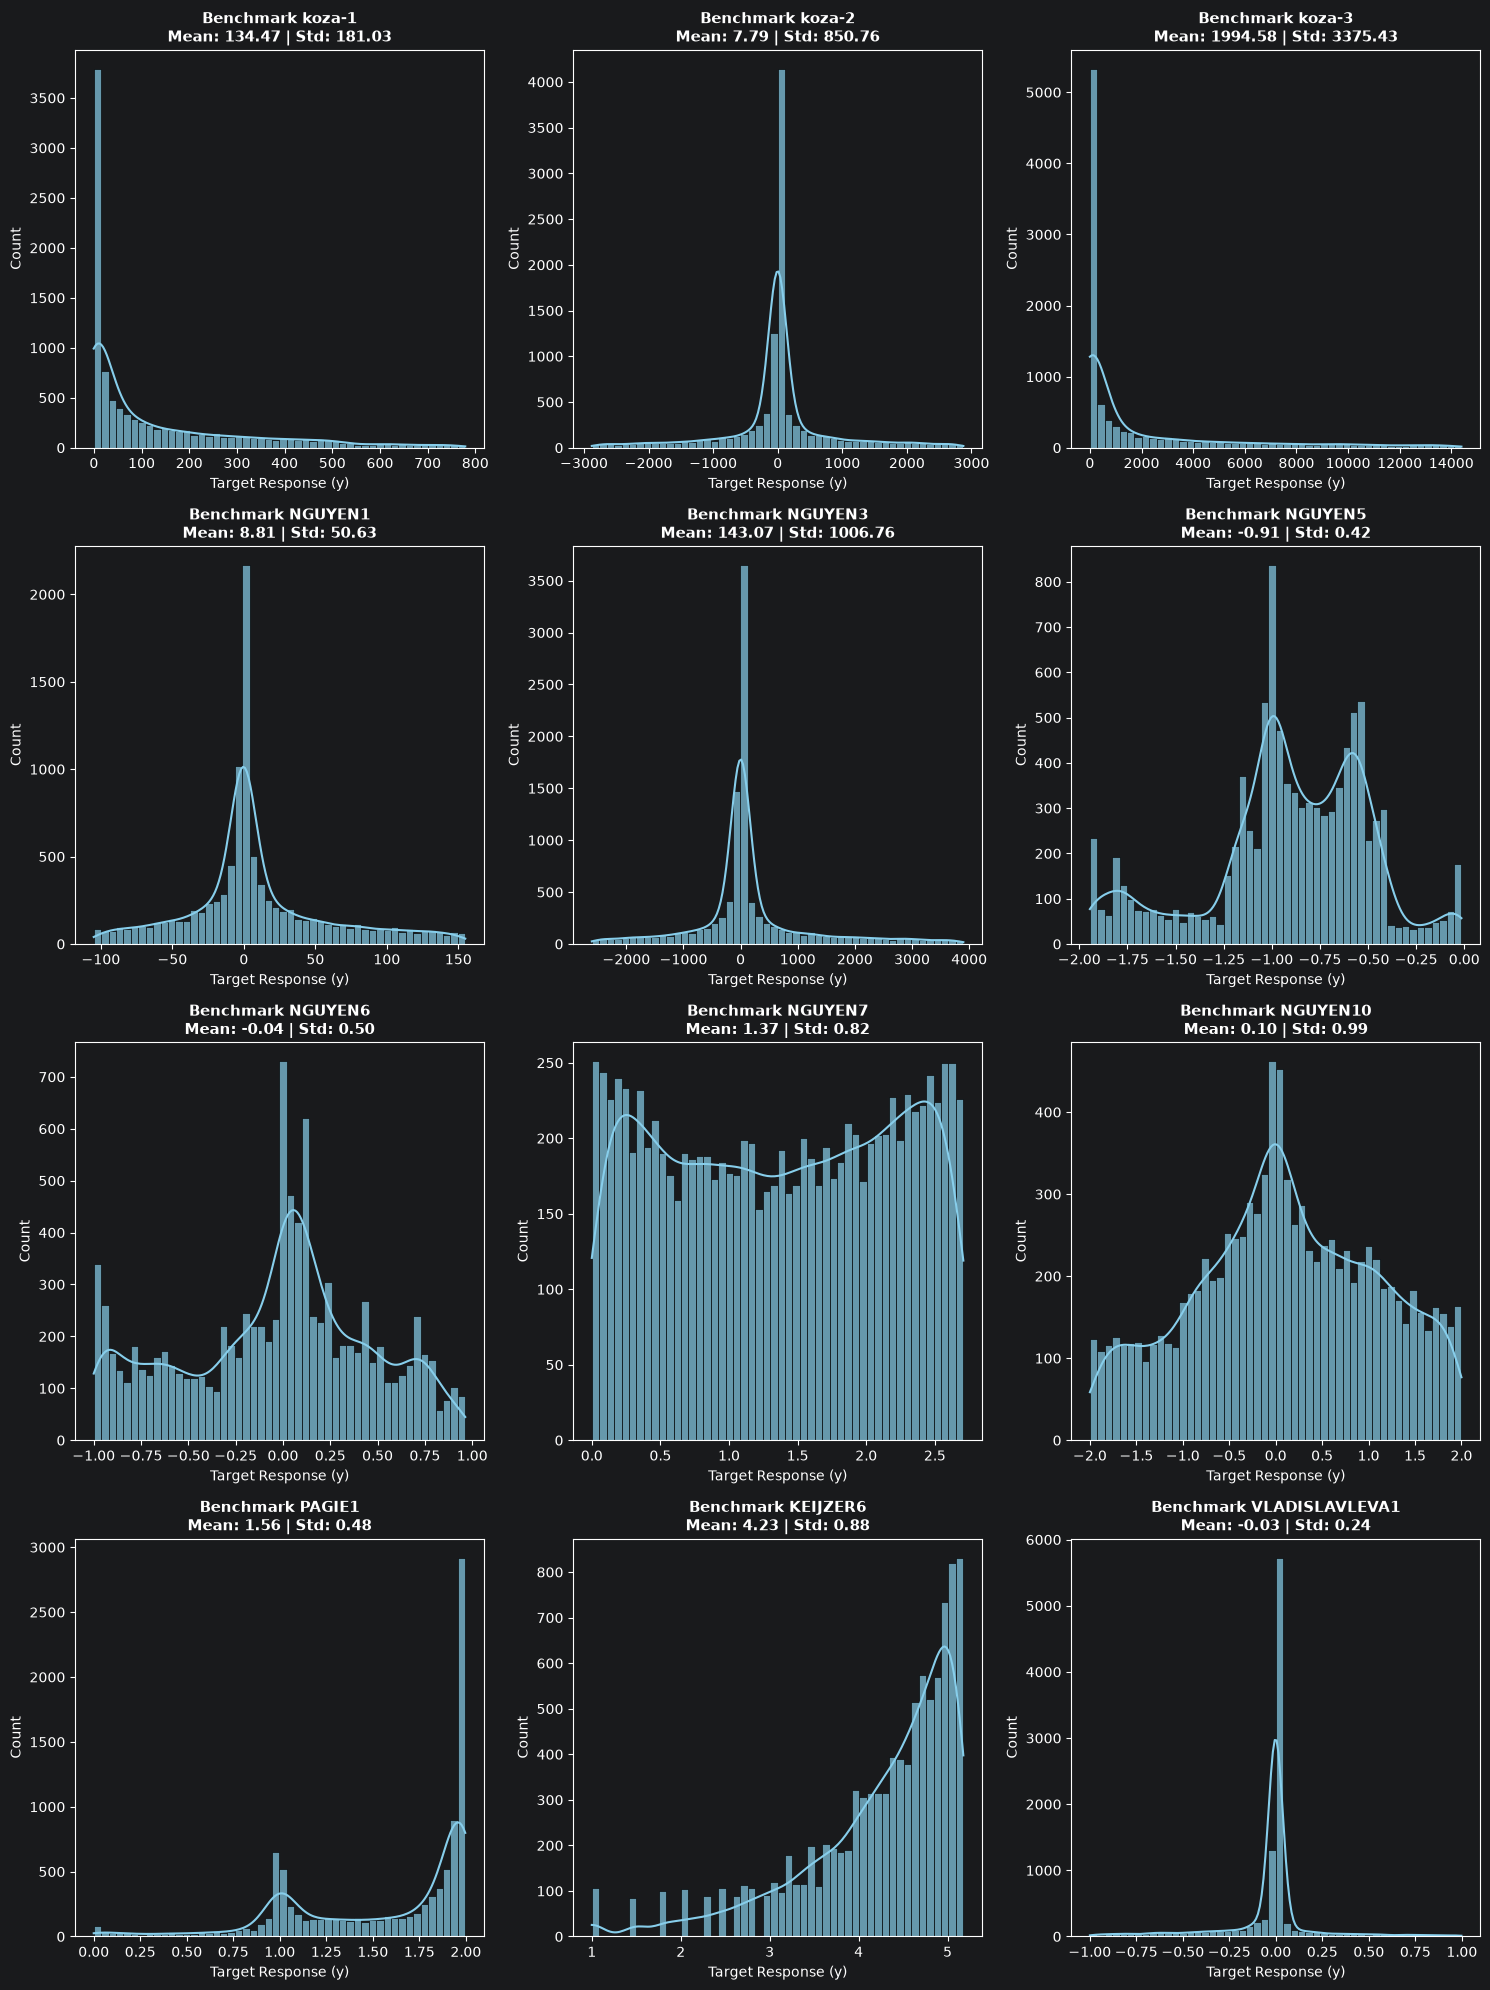

In [4]:
def plot_all_benchmarks_histogram(n_samples=10000, random_state=42, benchmarks = []):
    """
    Plots a 2x3 grid of histograms showing target distributions across all benchmark functions.
    """
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten()

    for idx, b_name in enumerate(benchmarks):
        X_tr, y_tr, _, _ = get_benchmark_dataset(b_name, n_train=n_samples, random_state=random_state)

        # Clip extreme asymptote values for H1/F16 (tan x) so outliers don't flatten the plot
        if b_name == 'H1':
            y_display = np.clip(y_tr, -100, 100)
            title_suffix = " (Clipped [-100, 100])"
        else:
            y_display = y_tr
            title_suffix = ""

        ax = axes[idx]
        sns.histplot(y_display, bins=50, kde=True, ax=ax, color='skyblue', edgecolor='black', alpha=0.7)

        # Summary stats in title
        ax.set_title(
            f"Benchmark {b_name}{title_suffix}\nMean: {np.mean(y_tr):.2f} | Std: {np.std(y_tr):.2f}",
            fontsize=11,
            fontweight='bold'
        )
        ax.set_xlabel("Target Response (y)")
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

# Run combined plotting function
plot_all_benchmarks_histogram(benchmarks=benchmarks)

In [5]:
# Training Settings

def get_params(random_seed):
    return dict(
    population_size=500,
    generations=200,
    stopping_criteria=0.0001,
    tournament_size= 20,
    p_crossover=0.7,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.05,
    p_point_mutation=0.1,
    max_samples=0.9,
    verbose=1,
    parsimony_coefficient=0.01,
    random_state=random_seed,
    metric='rmse',
    n_elites=1,

    function_set = ('add', 'sub', 'mul','div', 'sqrt', 'log',
            'abs', 'neg', 'inv',
            'max', 'min',
            'sin', 'cos', 'tan'
            ),
)

master_rng = np.random.default_rng(seed=42)
random_seeds = master_rng.integers(low=0, high=10000, size=4).tolist()
print(f"Random Seeds = {random_seeds}")
# random_seeds = [7739]

Random Seeds = [892, 7739, 6545, 4388]


In [6]:
results = []
for seed in random_seeds:
    print(f"\n==================== SEED {seed} ====================")

    for name in benchmarks:
        # 1. Load dataset using the current seed
        X_train, y_train, X_test, y_test = get_benchmark_dataset(name, random_state=seed)

        # 2. Instantiate GP with current random_state
        est_gp = SymbolicRegressor(**get_params(seed))
        print(f"\n====================================================================================")
        print(f"Benchmark Running = {name}")

        # 3. Train GP
        print(f"Benchmark: {name}")
        est_gp.fit(X_train, y_train)

        # 4. Predict and clean numerical issues
        y_pred = est_gp.predict(X_test)
        y_pred = np.nan_to_num(y_pred, nan=0.0, posinf=1e5, neginf=-1e5)

        # 5. Calculate Test R2
        r2 = r2_score(y_test, y_pred)
        r2_scores = [r2_score(y_train, program.execute(X_train)) for program in est_gp.best_programs_per_gen]


        # 6. Record findings
        results.append({
            'Seed': seed,
            'Benchmark': name,
            'R2_Score': r2,
            'Formula': str(est_gp._program),

            # Data Per Generation
            'Population Distribution': est_gp.population_distribution,
            'Population R2 Scores': r2_scores,
        })



==================== SEED 892 ====================

Benchmark Running = koza-1
Benchmark: koza-1
    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    10.50          211.501       16          172.449          401.445      2.28m
   1     4.38          216.799        6          166.143          424.109      1.93m
   2     3.52          207.628        6          166.143          424.109      1.79m
   3     3.01          207.767        3          168.394          418.878      1.77m
   4     3.00          216.067        2          168.614           424.66      1.77m
   5     2.52          207.741        1          170.048          413.387      1.75m
   6     2.53          207.492        1          170.048          413.387      1.69m
   7     2.08          208.292        1          170.048      


--- Summary Performance across seeds ---
         Benchmark      mean       std
0         KEIJZER6  0.999367  0.000216
1          NGUYEN1  0.991843  0.016310
2         NGUYEN10  0.515658  0.066538
3          NGUYEN3  0.308015  0.388110
4          NGUYEN5 -0.006780  0.006199
5          NGUYEN6 -0.192760  0.246093
6          NGUYEN7  0.999035  0.000991
7           PAGIE1  0.788886  0.040389
8   VLADISLAVLEVA1  0.011562  0.047483
9           koza-1  0.962737  0.042876
10          koza-2  0.326426  0.374742
11          koza-3 -0.342704  0.041713


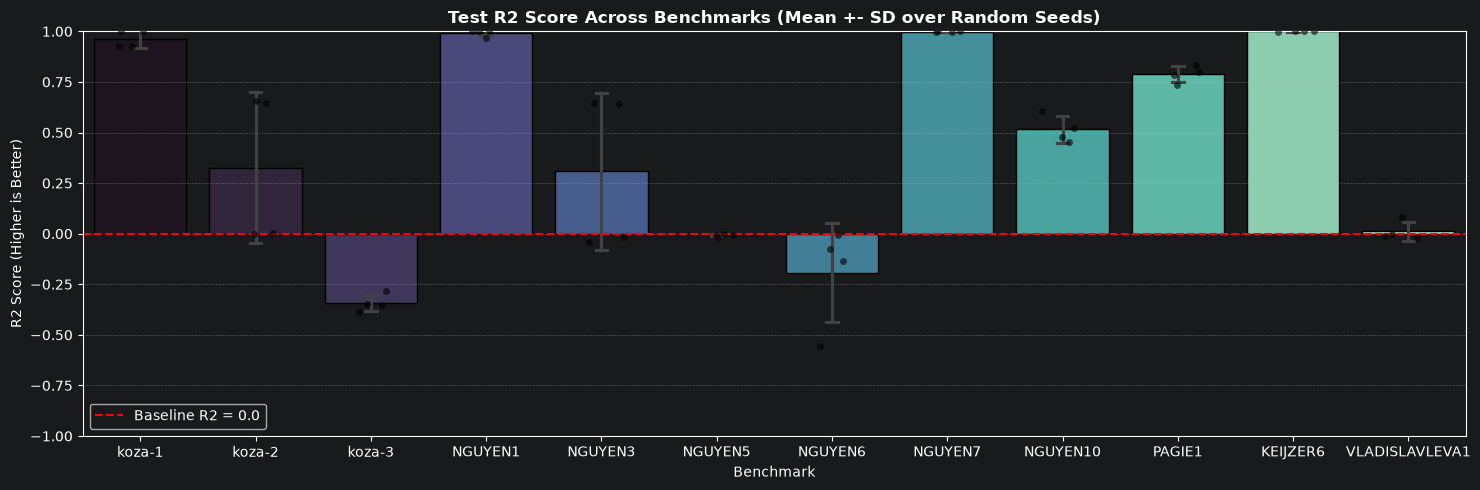

In [7]:
# Convert results into a DataFrame
df_results = pd.DataFrame(results)

# Display summary table with mean and standard deviation across seeds
df_summary = df_results.groupby('Benchmark')['R2_Score'].agg(['mean', 'std']).reset_index()
print("\n--- Summary Performance across seeds ---")
print(df_summary)

# Plot Bar Chart comparison across benchmarks with error bars (representing variability across seeds)
plt.figure(figsize=(15, 5))
sns.barplot(
    data=df_results,
    x='Benchmark',
    y='R2_Score',
    hue='Benchmark',
    palette='mako',
    errorbar='sd',       # Shows standard deviation across seeds
    capsize=0.1,         # Adds caps to error bars
    legend=False,
    edgecolor='black'
)

# Overlay individual seed points
sns.stripplot(
    data=df_results,
    x='Benchmark',
    y='R2_Score',
    color='black',
    alpha=0.6,
    jitter=0.2,
    size=5
)

plt.axhline(0, color='red', linestyle='--', label='Baseline R2 = 0.0')
plt.ylim(top=1, bottom=-1.0)
plt.title('Test R2 Score Across Benchmarks (Mean +- SD over Random Seeds)', fontsize=12, fontweight='bold')
plt.ylabel('R2 Score (Higher is Better)')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

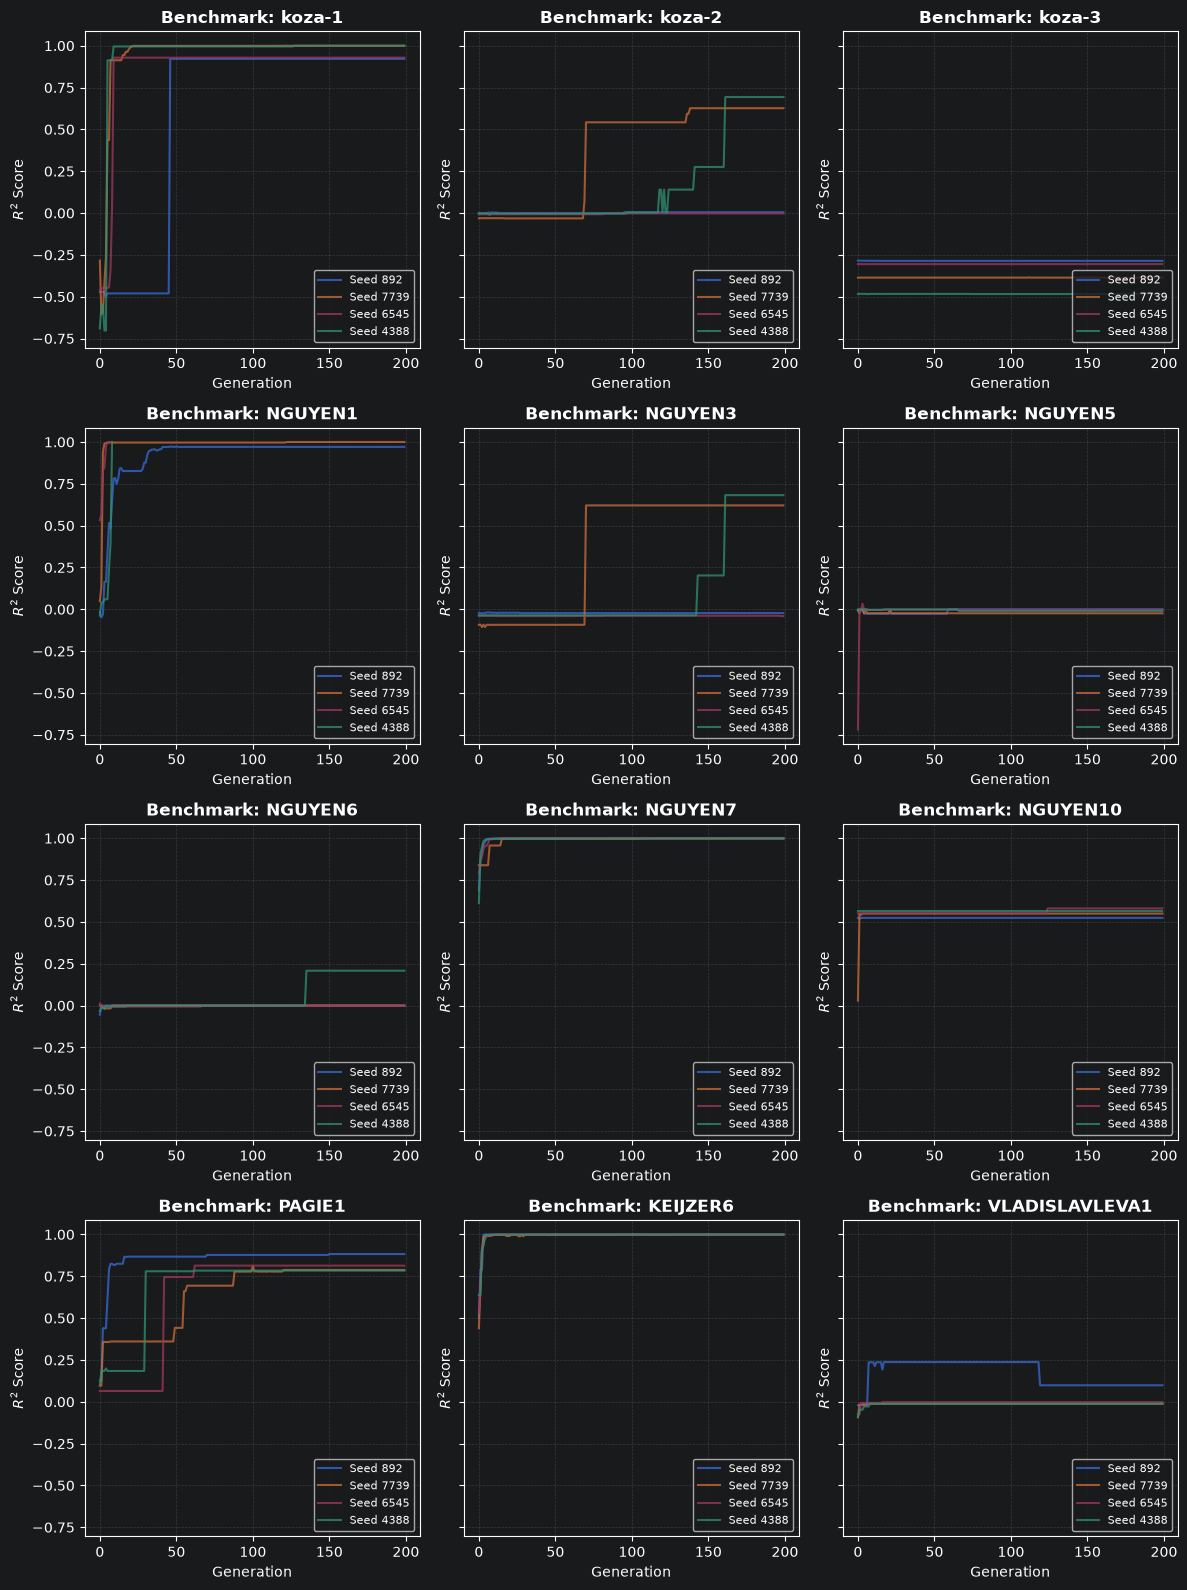

In [8]:
# Plot Best Program per Generation (R2 Score)

# 1. Group records by benchmark name directly from new_result
benchmark_groups = defaultdict(list)
for record in results:
    benchmark_groups[record["Benchmark"]].append(record)

# 2. Set up subplots dynamically based on benchmark count
n_benchmarks = len(benchmark_groups)
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharey=True)
axes = axes.flatten()

# Iterate through each benchmark
for idx, (b_name, records) in enumerate(benchmark_groups.items()):
    for record in records:
        seed = record["Seed"]
        r2_scores = record["Population R2 Scores"]
        ax = axes[idx]

        # Plot line for this specific seed
        ax.plot(
            range(len(r2_scores)),
            r2_scores,
            marker='o',
            markersize=0,
            linewidth=1.5,
            label=f'Seed {seed}',
            alpha=0.75
        )

        # Subplot formatting per benchmark
        ax.set_title(f'Benchmark: {b_name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Generation')
        ax.set_ylabel('$R^2$ Score')
        # ax.set_ylim(-1.50, 1.50)  # Set limit on each axis object
        ax.grid(True, linestyle='--', alpha=0.2)
        ax.legend(loc='lower right', fontsize=8)

# Hide any remaining unused subplots in the grid
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

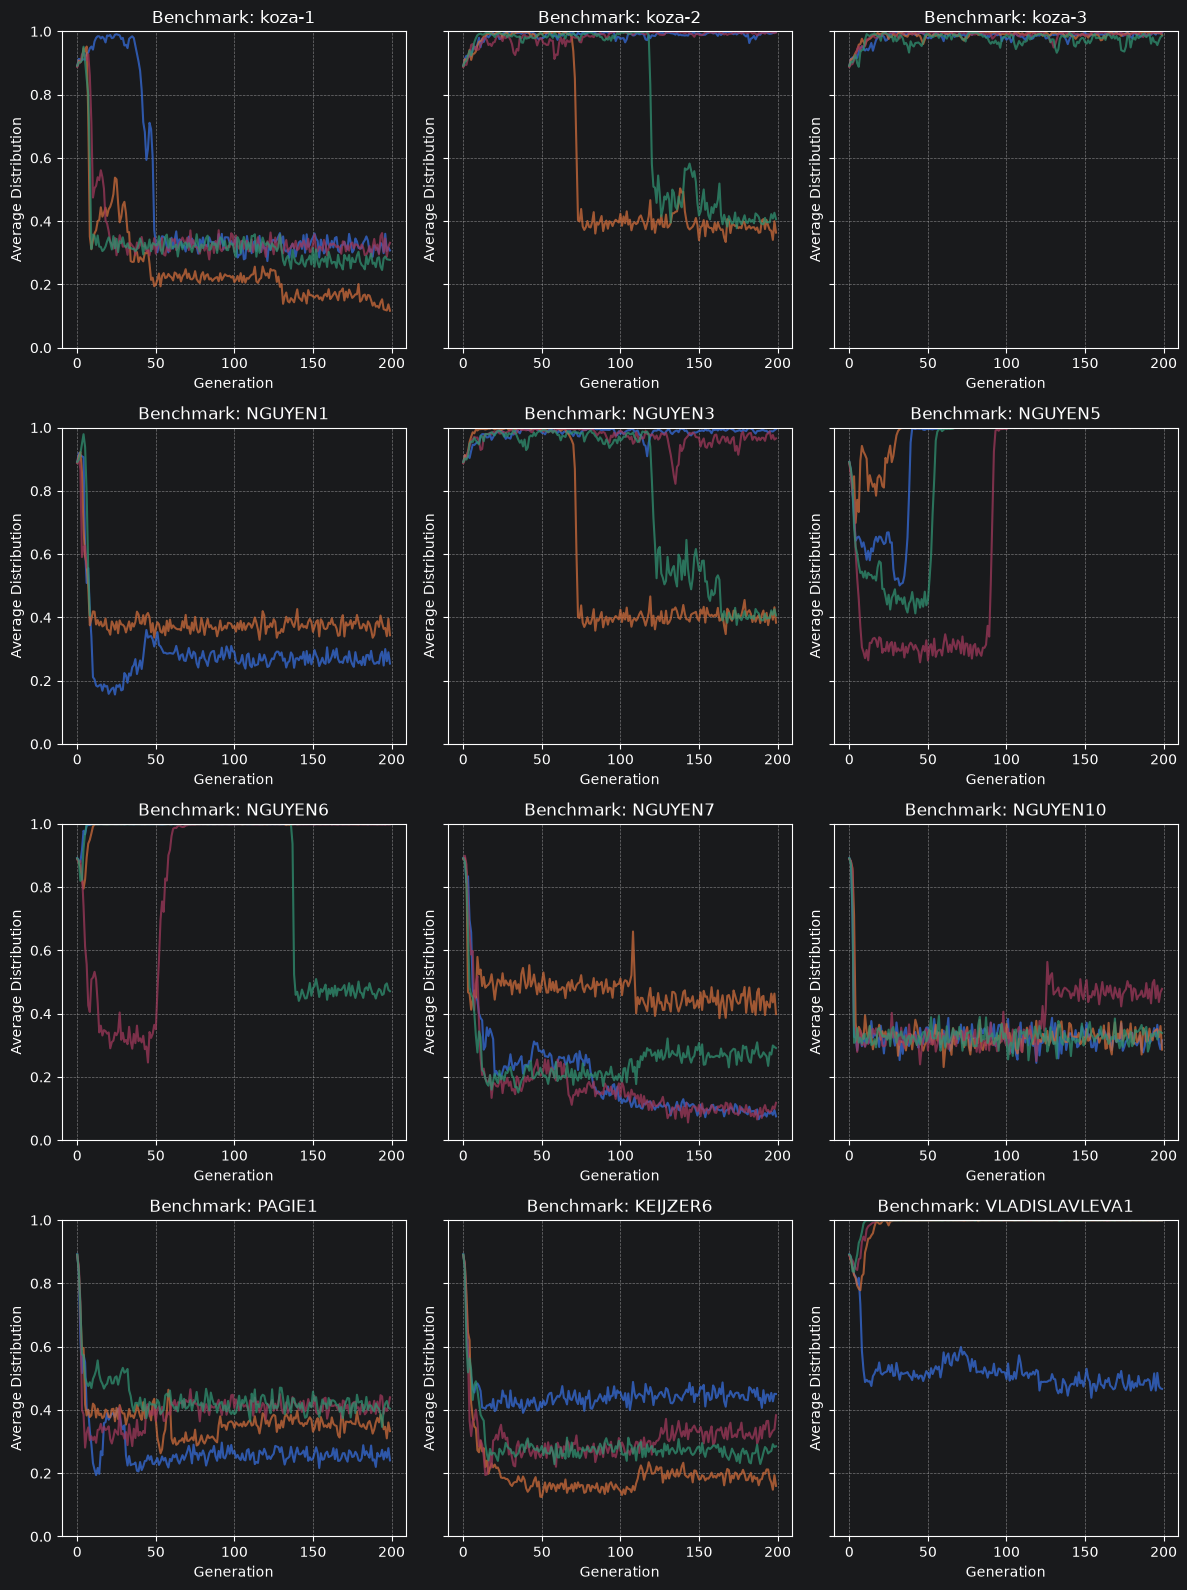

In [9]:
# Plot Population Distribution

# 1. Group records by benchmark name directly from new_result
benchmark_groups = defaultdict(list)
for record in results:
    benchmark_groups[record["Benchmark"]].append(record)

# 2. Set up subplots dynamically based on benchmark count
n_benchmarks = len(benchmark_groups)
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharey=True)
axes = axes.flatten()

# Iterate through each benchmark
for idx, (b_name, records) in enumerate(benchmark_groups.items()):
    for record in records:
        seed = record["Seed"]
        distributions = record["Population Distribution"]
        ax = axes[idx]

        # Plot in designated subplot
        ax = axes[idx]
        ax.plot(range(len(distributions)), distributions, marker='o', markersize=0, linewidth=1.5, label=b_name, alpha=0.75)
        ax.set_title(f'Benchmark: {b_name}', fontsize=12)
        ax.set_xlabel('Generation')
        ax.set_ylabel('Average Distribution')
        ax.grid(True, linestyle='--', alpha=0.6)
        # ax.legend()

# Hide unused subplots if num_models is odd
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.ylim(0, 1)
plt.show()

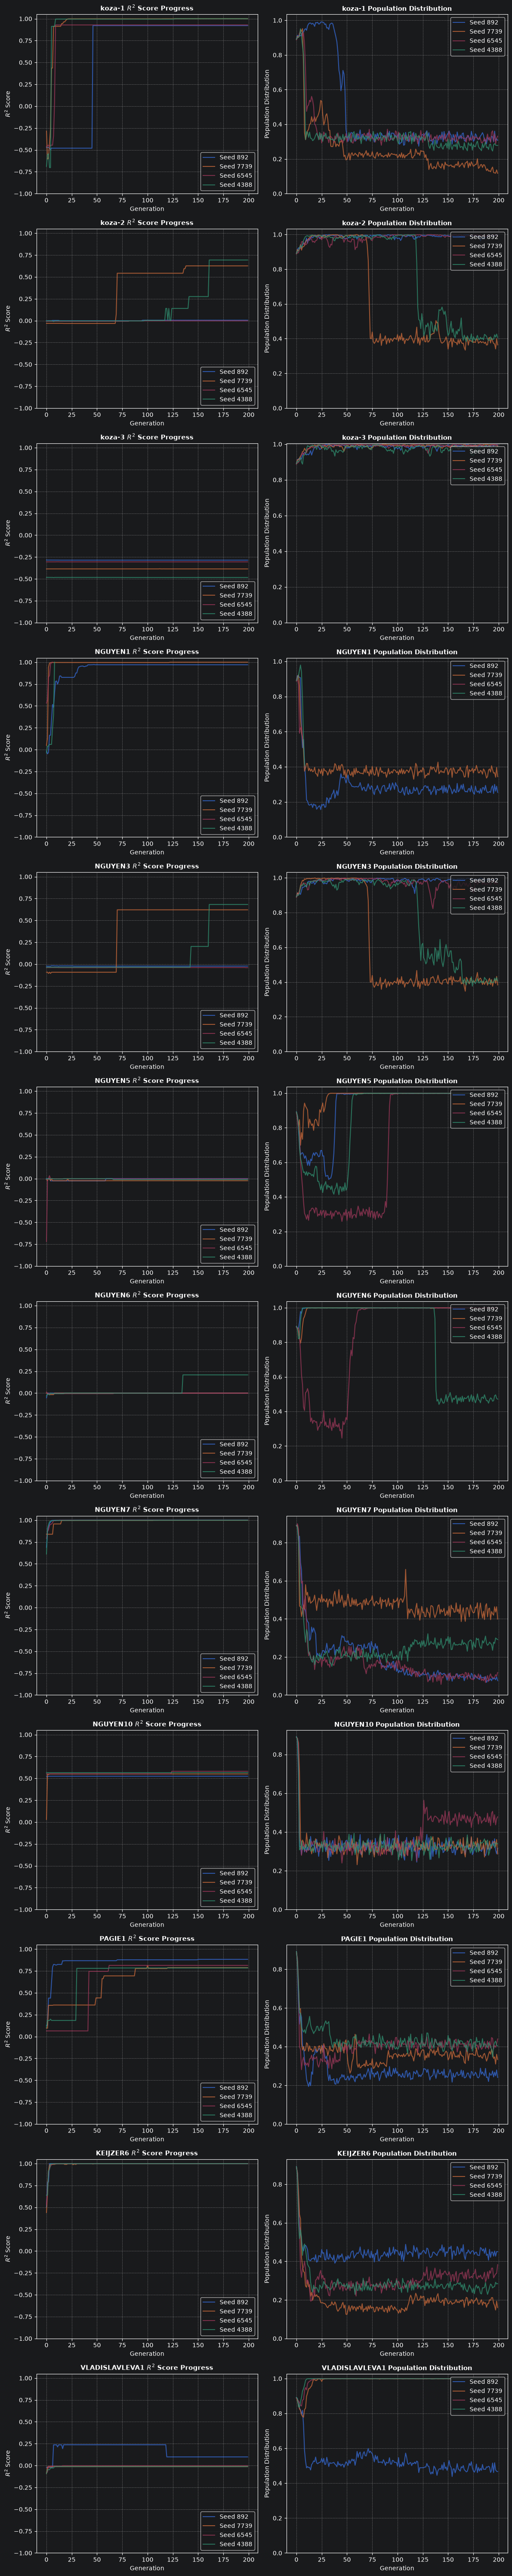

In [10]:
# Plot Fitness vs Distribution

# 1. Group records by benchmark name directly from new_result
benchmark_groups = defaultdict(list)
for record in results:
    benchmark_groups[record["Benchmark"]].append(record)

# 2. Set up subplots dynamically based on benchmark count
n_benchmarks = len(benchmark_groups)
fig, axes = plt.subplots(
    n_benchmarks, 2, figsize=(12, 5 * n_benchmarks), squeeze=False
)

# 3. Iterate through grouped data
for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
    ax_r2 = axes[row_idx, 0]
    ax_distribution = axes[row_idx, 1]

    for record in records:
        seed = record["Seed"]
        distributions = record["Population Distribution"]
        r2_scores = record["Population R2 Scores"]

        # Plot Prey R2 Score on Left Subplot
        ax_r2.plot(
            range(len(r2_scores)),
            r2_scores,
            linewidth=1.5,
            label=f"Seed {seed}",
            alpha=0.75,
        )

        # Plot Predator Fitness on Right Subplot
        ax_distribution.plot(
            range(len(distributions)),
            distributions,
            linewidth=1.5,
            label=f"Seed {seed}",
            alpha=0.75,
        )

    # Formatting Left (Prey R2 Score)
    ax_r2.set_title(
        f"{b_name} $R^2$ Score Progress", fontsize=11, fontweight="bold"
    )
    ax_r2.set_xlabel("Generation")
    ax_r2.set_ylabel("$R^2$ Score")
    ax_r2.set_ylim(-1, 1.05)
    ax_r2.grid(True, linestyle="--", alpha=0.6)
    ax_r2.legend(loc="lower right")

    # Formatting Right (Predator Fitness)
    ax_distribution.set_title(
        f"{b_name} Population Distribution", fontsize=11, fontweight="bold"
    )
    ax_distribution.set_xlabel("Generation")
    ax_distribution.set_ylabel("Population Distribution")
    ax_distribution.set_ylim(bottom=0)
    ax_distribution.grid(True, linestyle="--", alpha=0.6)
    ax_distribution.legend(loc="upper right")

plt.tight_layout()
plt.show()